In [2]:
# Install scanpy
!pip install scanpy

# Import libraries
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

# Set verbosity to show details
sc.settings.verbosity = 3

# Load a standard, publicly available RNA-seq dataset (PBMC 3K from 10x Genomics)
adata = sc.datasets.pbmc3k()
print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


In [3]:
# Filter out cells that have fewer than 200 genes expressed
sc.pp.filter_cells(adata, min_genes=200)

# Filter out genes that are detected in fewer than 3 cells
sc.pp.filter_genes(adata, min_cells=3)

# Calculate mitochondrial genes (high mitochondrial content means a dying cell)
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print("Quality Control Complete. Data shape is now:", adata.shape)

filtered out 19024 genes that are detected in less than 3 cells
Quality Control Complete. Data shape is now: (2700, 13714)


normalizing counts per cell
    finished (0:00:04)


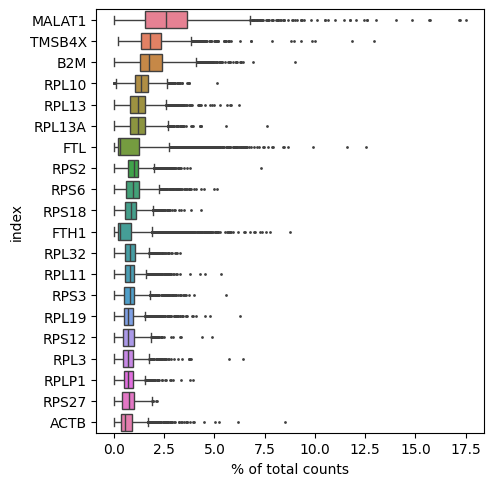

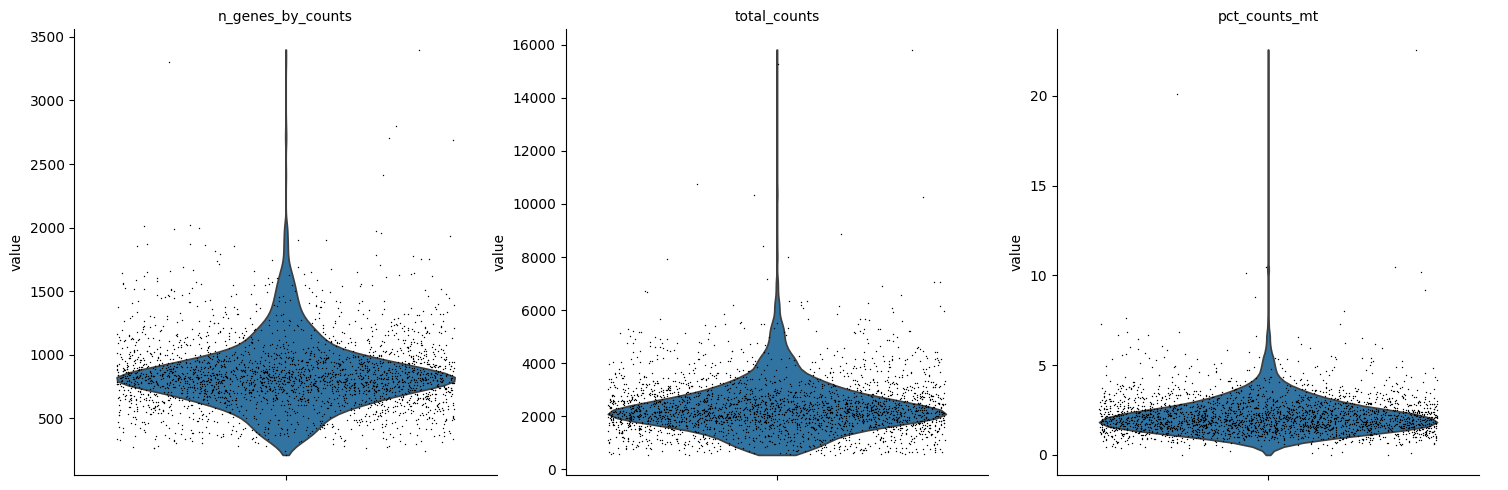

In [4]:
# Visualize the top 20 most highly expressed genes
sc.pl.highest_expr_genes(adata, n_top=20)

# Show a violin plot of the Quality Control metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)